#AI-Powered E-Commerce Analytics Platform

######A key feature of the platform is the integration of Generative AI, which automatically summarizes business performance, generates executive reports, explains dashboard insights in natural language, and provides an AI-powered chatbot that allows users to interact with business data using conversational queries. This enables non-technical users to access complex analytics through simple questions and receive intelligent recommendations.

Develop an intelligent e-commerce analytics platform that enables business owners to Monitor business performance through interactive dashboards,
Predict future sales using AI models, Understand customer satisfaction,
Recommend products to customers, Generate AI-driven business insights and reports, Interact with business data using natural language.


##Import all the libraries

In [57]:
!pip install transformers
!pip install torch
!pip install spacy
!python -m spacy download pt_core_news_sm
!pip install wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 113.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import stats
from scipy.stats import skew,kurtosis
import datetime as dt
import calendar
from matplotlib.gridspec import GridSpec
pd.set_option('display.max_columns', 100)
import plotly.offline as py
import plotly.express as px
import plotly.graph_objs as go
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,confusion_matrix,accuracy_score,f1_score,precision_score,recall_score)
import math
import warnings
warnings.filterwarnings('ignore')
import re
import string
import spacy
from pathlib import Path
from sklearn.preprocessing import PowerTransformer
from nltk.corpus import stopwords
import nltk
from wordcloud import WordCloud

from sklearn.metrics import f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier

# Defensive import block for PyTorch / HuggingFace BERTimbau
try:
    import torch
    from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
    BERTIMBAU_INSTALLED = True
except ImportError:
    BERTIMBAU_INSTALLED = False

import joblib

##Load dataset

In [59]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/IIT Palakkad Advanced AI/olist_master_dataset.csv')

In [60]:
#copy original data for preprocessing
df=data.copy()

##Data understanding

In [61]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,1.0,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,3.0,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,2.0,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,1.0,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,perfumery
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,1.0,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,auto


In [62]:
df.shape

(119143, 37)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 37 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       119143 non-null  object 
 1   customer_id                    119143 non-null  object 
 2   order_status                   119143 non-null  object 
 3   order_purchase_timestamp       119143 non-null  object 
 4   order_approved_at              118966 non-null  object 
 5   order_delivered_carrier_date   117057 non-null  object 
 6   order_delivered_customer_date  115722 non-null  object 
 7   order_estimated_delivery_date  119143 non-null  object 
 8   customer_unique_id             119143 non-null  object 
 9   customer_zip_code_prefix       119143 non-null  int64  
 10  customer_city                  119143 non-null  object 
 11  customer_state                 119143 non-null  object 
 12  order_item_id                 

In [64]:
#Convert all date columns
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date',
    'review_creation_date',
    'review_answer_timestamp'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [65]:
#Statistical summary (Categorical)
df.describe(include='object')

,order_id,customer_id,order_status,customer_unique_id,customer_city,customer_state,product_id,seller_id,product_category_name,payment_type,review_id,review_comment_title,review_comment_message,product_category_name_english
count,119143,119143,119143,119143,119143,119143,118310,118310,116601,119140,118146,13989,50245,116576
unique,99441,99441,8,96096,4119,27,32951,3095,73,5,98410,4527,36159,71
top,895ab968e7bb0d5659d16cd74cd1650c,270c23a11d024a44c896d1894b261a83,delivered,9a736b248f67d166d2fbb006bcb877c3,sao paulo,SP,aca2eb7d00ea1a7b8ebd4e68314663af,4a3ca9315b744ce9f8e9374361493884,cama_mesa_banho,credit_card,eef5dbca8d37dfce6db7d7b16dd0525e,Recomendo,Muito bom,bed_bath_table
freq,63,63,115723,75,18875,50265,536,2155,11988,87776,63,494,259,11988


##EDA(Exploratory Data Analysis)
Objective -Discover patterns, trends, and anomalies in the data.

In [66]:
df.nunique()

,0
order_id,99441
customer_id,99441
order_status,8
order_purchase_timestamp,98875
order_approved_at,90733
order_delivered_carrier_date,81018
order_delivered_customer_date,95664
order_estimated_delivery_date,459
customer_unique_id,96096
customer_zip_code_prefix,14994


In [67]:
df.order_status.unique()

array(['delivered', 'invoiced', 'shipped', 'processing', 'unavailable',
       'canceled', 'created', 'approved'], dtype=object)

In [68]:
df.review_score.unique()

array([ 4.,  5.,  2.,  1., nan,  3.])

In [69]:
df['order_status'].value_counts()

,count
order_status,
delivered,115723
shipped,1256
canceled,750
unavailable,652
invoiced,378
processing,376
created,5
approved,3


In [70]:
#Top 10 states with the highest number of customers
top_states=df['customer_state'].value_counts().head(10)
top_states

,count
customer_state,
SP,50265
RJ,15518
MG,13819
RS,6573
PR,6043
SC,4345
BA,4091
DF,2516
GO,2466


In [71]:
#Total unique customers
df['customer_unique_id'].nunique()

96096

In [72]:
#Delivery Success Rate
delivery_success_rate = ((df['order_status'] == 'delivered').sum()/ len(df)) * 100

print(f"Delivery Success Rate: {delivery_success_rate:.2f}%")

Delivery Success Rate: 97.13%


###Review Analysis

In [73]:
df['review_comment_title'] = df['review_comment_title'].fillna('No Title')
df['review_comment_message'] = df['review_comment_message'].fillna('No Review')
df['review_comment_title'].isnull().sum()
df['review_comment_message'].isnull().sum()

np.int64(0)

In [74]:
#How does delivery time affect customer ratings?
df["delivery_days"] = (pd.to_datetime(df["order_delivered_customer_date"]) - pd.to_datetime(df["order_purchase_timestamp"])).dt.days

delivery_review = (df.groupby("review_score")["delivery_days"].mean())

delivery_review

,delivery_days
review_score,
1.0,19.099992
2.0,15.381893
3.0,13.552435
4.0,11.778330
5.0,10.203253


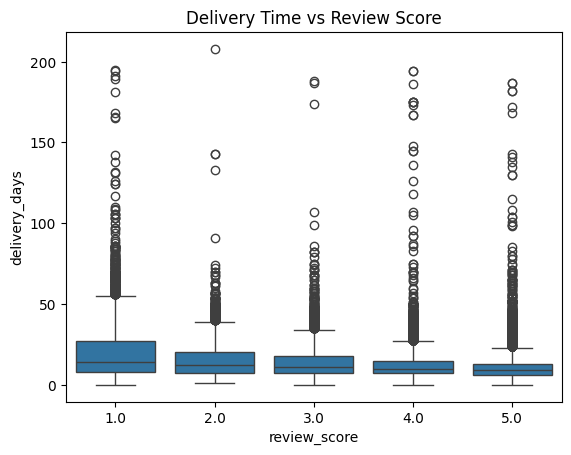

In [75]:
sns.boxplot(
    data=df,
    x="review_score",
    y="delivery_days"
)

plt.title("Delivery Time vs Review Score")
plt.show()

In [76]:
#What are customers saying in reviews?
df["review_score"].value_counts().sort_index()

,count
review_score,
1.0,15428
2.0,4162
3.0,9894
4.0,22319
5.0,66343


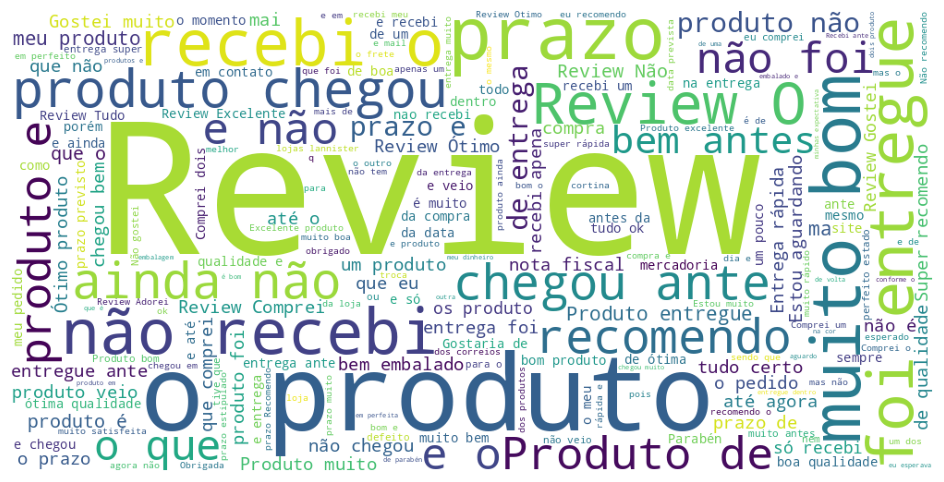

In [77]:
#Most Common Portuguese Words
from wordcloud import WordCloud

text = " ".join(
    df["review_comment_message"]
      .dropna()
      .astype(str)
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [78]:
#Sentiment Distribution
def sentiment(score):
    if score <= 2:
        return "Negative"
    elif score == 3:
        return "Neutral"
    else:
        return "Positive"

df["sentiment"] = df["review_score"].apply(sentiment)

df["sentiment"].value_counts()

,count
sentiment,
Positive,89659
Negative,19590
Neutral,9894


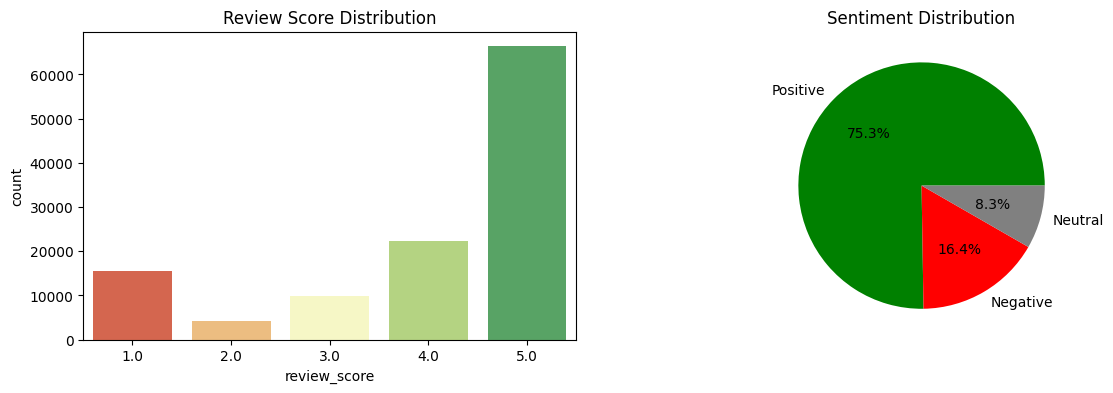

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=df, x="review_score", ax=axes[0], palette="RdYlGn")
axes[0].set_title("Review Score Distribution")
df["sentiment"].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=axes[1],colors=["green", "red", "gray"])
axes[1].set_title("Sentiment Distribution")
axes[1].set_ylabel("")
plt.show()

#####Insight: ~75% positive (4–5 stars), ~16% negative (1–2 stars). Score distribution is bimodal — customers leave either 5 or 1, rarely 2–3.

In [80]:
#Delivery features
df['delivery_delay'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days

In [81]:
# Categorical delivery status derived
df["delivery_status"] = np.where(df["delivery_delay"] > 0, "Late", "On Time")
df.loc[df["order_delivered_customer_date"].isnull(), "delivery_status"] = "Not Delivered Yet"

           has_comment  comment_length
sentiment                             
Negative           1.0           88.37
Neutral            1.0           52.96
Positive           1.0           33.82


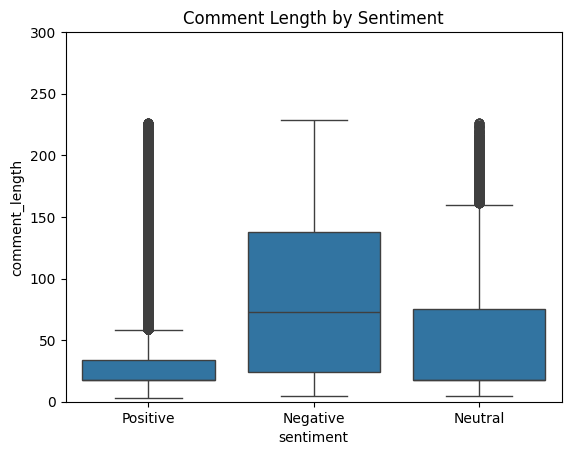

In [82]:
#Do unhappy customers write more?
df["review_text"] = (
    df["review_comment_title"].fillna("") + " " +
    df["review_comment_message"].fillna("")
).str.strip()

df["has_comment"] = (df["review_text"] != "").astype(int)
df["comment_length"] = df["review_text"].str.len()

print(df.groupby("sentiment")[["has_comment", "comment_length"]].mean().round(2))

sns.boxplot(data=df[df["comment_length"] > 0],x="sentiment", y="comment_length")
plt.ylim(0, 300)
plt.title("Comment Length by Sentiment")
plt.show()

######Insight: Negative reviews are far more likely to include text and are longer — great justification for the BERTimbau sentiment module (complaint mining).

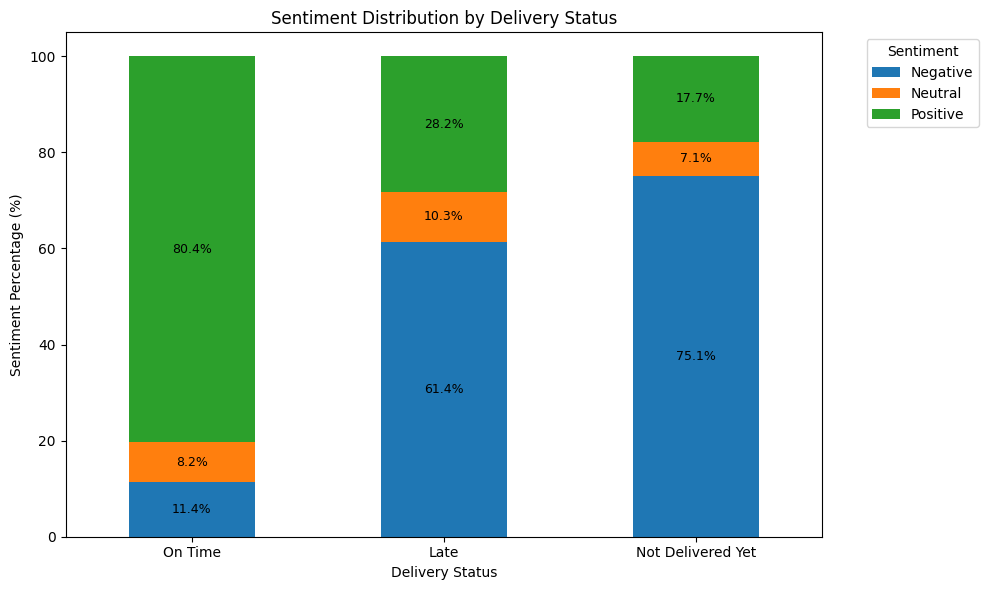

In [83]:
# Crosstab: delivery status × sentiment
sentiment_delivery = pd.crosstab(
    df["delivery_status"],
    df["sentiment"],
    normalize="index"
) * 100

# Optional: arrange delivery order
delivery_order = ["On Time", "Late", "Not Delivered Yet"]
sentiment_delivery = sentiment_delivery.reindex(
    [x for x in delivery_order if x in sentiment_delivery.index]
)

# Plot
ax = sentiment_delivery.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Sentiment Distribution by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Sentiment Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Sentiment", bbox_to_anchor=(1.05, 1), loc="upper left")

# Add percentage labels
for container in ax.containers:
    labels = [
        f"{bar.get_height():.1f}%" if bar.get_height() > 3 else ""
        for bar in container
    ]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=9)

plt.tight_layout()
plt.savefig("sentiment_by_delivery_status.png", dpi=300, bbox_inches="tight")
plt.show()

####Cross-tabulating predicted sentiment against fulfillment performance reveals that late delivery is the #1 root cause of customer dissatisfaction in Olist:


Executive Finding: Majority of all negative reviews are driven by courier shipping delays exceeding the estimated delivery date and for not delivered, not by seller product defects.

####Identify Top Categories by Review Volume
First, we'll identify the product categories with the highest number of reviews. This focuses our analysis on categories with sufficient data for meaningful sentiment insights.

In [84]:
# Calculate the total number of reviews per category
review_counts_by_category = df['product_category_name_english'].value_counts()

# Exclude 'Unknown' category if it exists and is not desired in top categories
if 'Unknown' in review_counts_by_category.index:
    review_counts_by_category = review_counts_by_category.drop('Unknown')

# Display the top 10 categories by review volume
top_n = 10 # You can change this to 20 or any other number
top_categories_by_volume = review_counts_by_category.head(top_n)

print(f"Top {top_n} Product Categories by Review Volume:")
display(top_categories_by_volume)

# Get the list of top category names for filtering
top_category_names = top_categories_by_volume.index.tolist()

Top 10 Product Categories by Review Volume:


,count
product_category_name_english,
bed_bath_table,11988
health_beauty,10032
sports_leisure,9004
furniture_decor,8832
computers_accessories,8150
housewares,7380
watches_gifts,6213
telephony,4726
garden_tools,4590


####Analyze Sentiment Distribution within Top Categories
Now, for these high-volume categories, we will examine their sentiment distribution (positive, neutral, and negative percentages) to understand customer satisfaction patterns.

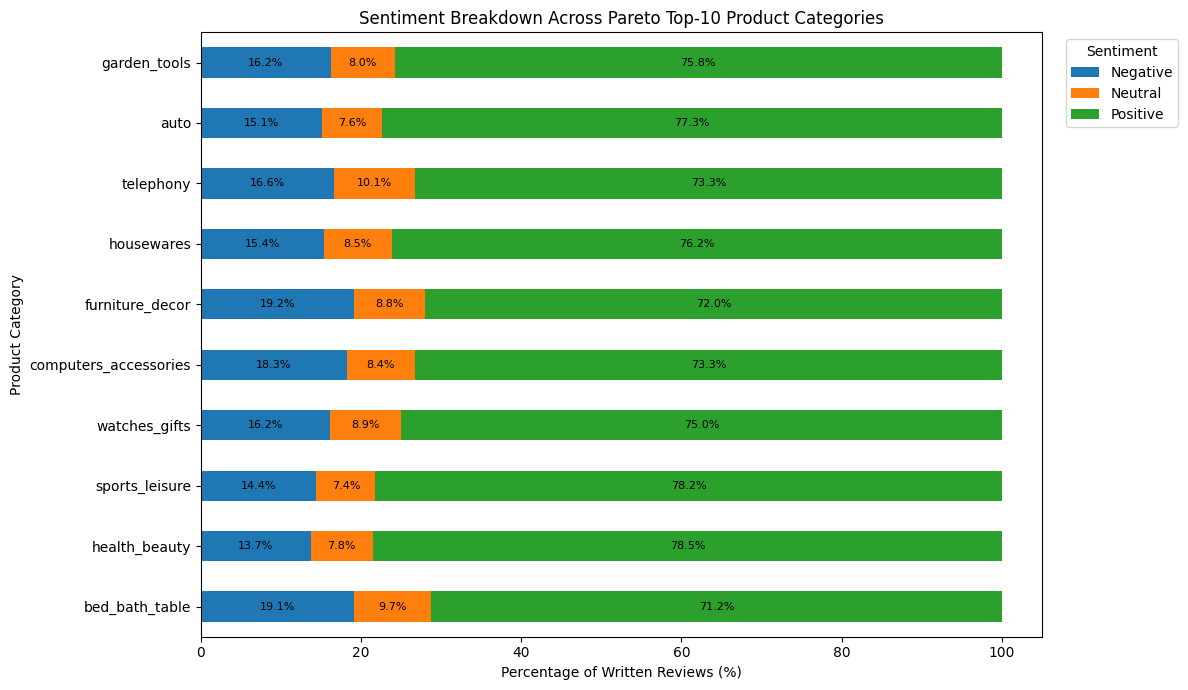

In [85]:
# Pareto Top-10 categories
top_10_categories = [
    "bed_bath_table",
    "health_beauty",
    "sports_leisure",
    "watches_gifts",
    "computers_accessories",
    "furniture_decor",
    "housewares",
    "telephony",
    "auto",
    "garden_tools"
]

# Filter to Top-10 categories
top10_df = df[
    df["product_category_name_english"].isin(top_10_categories)
].copy()

# Sentiment percentage within each category
sentiment_pct = pd.crosstab(
    top10_df["product_category_name_english"],
    top10_df["sentiment"],
    normalize="index"
) * 100

# Keep consistent sentiment order
sentiment_order = ["Negative", "Neutral", "Positive"]

sentiment_pct = sentiment_pct.reindex(
    columns=[s for s in sentiment_order if s in sentiment_pct.columns]
).fillna(0)

# Keep categories in Pareto order
sentiment_pct = sentiment_pct.reindex(
    [c for c in top_10_categories if c in sentiment_pct.index]
)

# Plot stacked horizontal bar chart
ax = sentiment_pct.plot(
    kind="barh",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Sentiment Breakdown Across Pareto Top-10 Product Categories")
plt.xlabel("Percentage of Written Reviews (%)")
plt.ylabel("Product Category")

# Add percentage labels
for container in ax.containers:
    labels = [
        f"{bar.get_width():.1f}%"
        if bar.get_width() >= 5 else ""
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=8
    )

plt.legend(
    title="Sentiment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

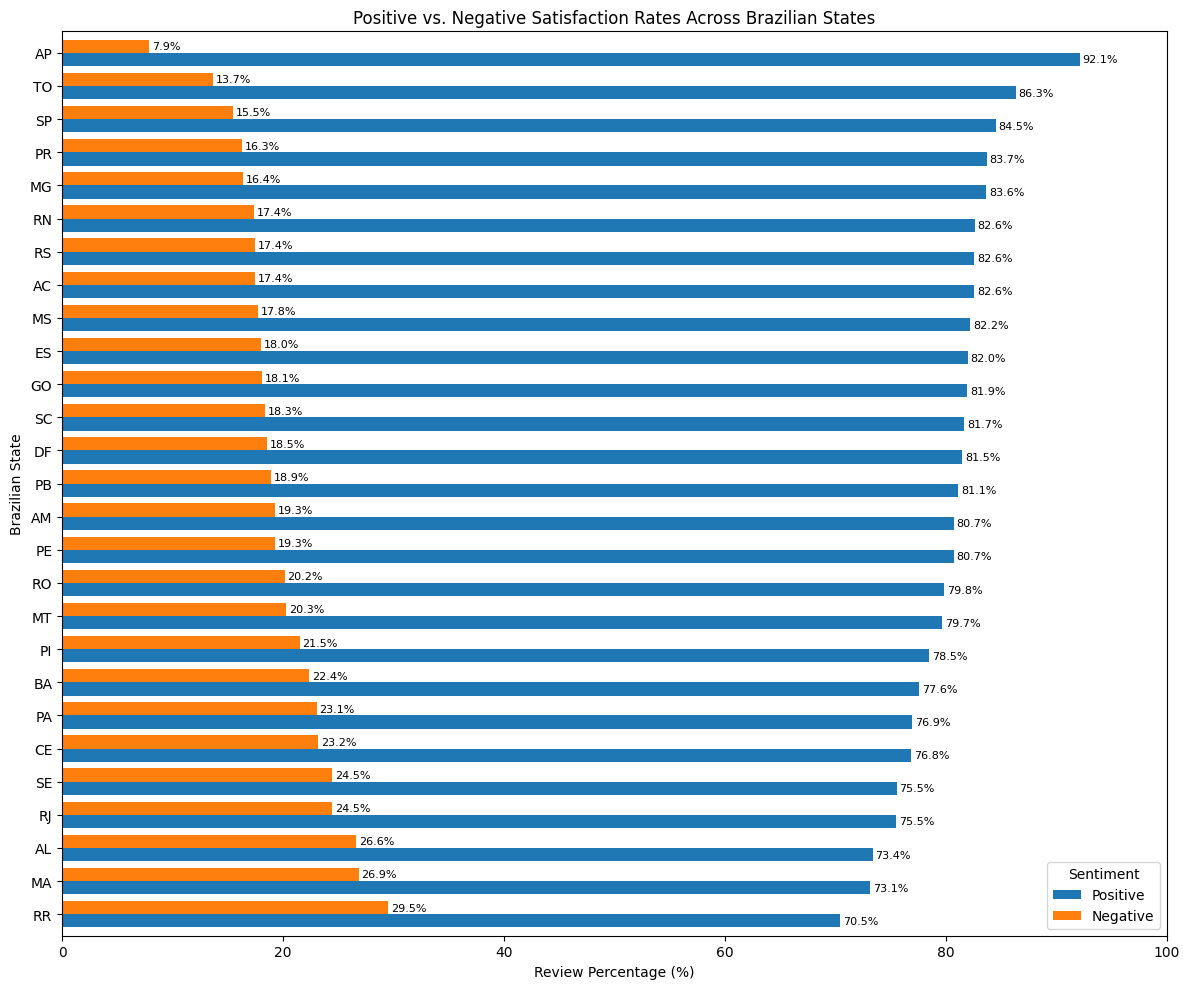

In [86]:
# Keep only Positive and Negative reviews
state_df = df[
    df["sentiment"].isin(["Positive", "Negative"])
].copy()

# Calculate sentiment percentages within each state
state_sentiment = pd.crosstab(
    state_df["customer_state"],
    state_df["sentiment"],
    normalize="index"
) * 100

# Ensure both columns exist and consistent order
state_sentiment = state_sentiment.reindex(
    columns=["Positive", "Negative"],
    fill_value=0
)

# Sort states by positive satisfaction rate
state_sentiment = state_sentiment.sort_values(
    "Positive",
    ascending=True
)

# Plot
ax = state_sentiment.plot(
    kind="barh",
    figsize=(12, 10),
    width=0.8
)

plt.title("Positive vs. Negative Satisfaction Rates Across Brazilian States")
plt.xlabel("Review Percentage (%)")
plt.ylabel("Brazilian State")
plt.xlim(0, 100)

# Add percentage labels
for container in ax.containers:
    labels = [
        f"{bar.get_width():.1f}%"
        if bar.get_width() >= 3 else ""
        for bar in container
    ]
    ax.bar_label(
        container,
        labels=labels,
        label_type="edge",
        fontsize=8,
        padding=2
    )

plt.legend(
    title="Sentiment",
    loc="lower right"
)

plt.tight_layout()


plt.show()

##Preprocessing

#####Duplicates

In [87]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

In [88]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'product_category_name_english',
       'delivery_days', 'sentiment', 'delivery_delay', 'delivery_status',
       'review_text', 'has_comment', 'comme

#####Drop unwanted columns for sentiment analysis

In [89]:
df_new=df.drop(columns=[

    'customer_id','order_id','seller_id',
    'customer_unique_id',
    'order_status',
    'order_item_id',
    'customer_city',
    'order_item_id',
    'product_id','review_creation_date',
    'order_purchase_timestamp','product_description_lenght','product_photos_qty','payment_type',
    'order_approved_at','payment_value',
    'order_delivered_carrier_date',
    'order_delivered_customer_date','review_answer_timestamp',
    'order_estimated_delivery_date',
    'customer_zip_code_prefix',
    'price',
    'shipping_limit_date',
    'product_category_name',
    'product_name_lenght',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'payment_sequential',
    'payment_installments',
    'freight_value','delivery_status',
    'delivery_days','review_text','customer_state','has_comment'

])

In [90]:
# review_id,sentiment,review_score,review_comment_title,review_comment_message,'delivery_delay',product_category_name_english,'comment_length'
df_new.head()

,review_id,review_score,review_comment_title,review_comment_message,product_category_name_english,sentiment,delivery_delay,comment_length
0,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",housewares,Positive,-8.0,179
1,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",housewares,Positive,-8.0,179
2,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",housewares,Positive,-8.0,179
3,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,perfumery,Positive,-6.0,37
4,e73b67b67587f7644d5bd1a52deb1b01,5.0,No Title,No Review,auto,Positive,-18.0,18


In [91]:
df_new.shape

(119143, 8)

In [92]:
df_new.columns

Index(['review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'product_category_name_english', 'sentiment',
       'delivery_delay', 'comment_length'],
      dtype='object')

In [93]:
missing_df = pd.DataFrame({
    'Null Count': df_new.isnull().sum(),
    'Null Percentage': (df_new.isnull().sum() / len(df_new)) * 100
})

missing_df = missing_df[missing_df['Null Count'] > 0]
missing_df = missing_df.sort_values(by='Null Count', ascending=False)

missing_df

,Null Count,Null Percentage
delivery_delay,3421,2.871339
product_category_name_english,2567,2.154554
review_score,997,0.836810
review_id,997,0.836810


In [94]:
# missing value fill with Unknown
df_new['delivery_delay'] = df_new['delivery_delay'].fillna('Unknown')

In [95]:
df_new['delivery_delay'].isna().sum()

np.int64(0)

In [96]:
# column with no review
df_new['review_score'] = df_new['review_score'].fillna('Unknown')

In [97]:
#Categorical columns
df_new['product_category_name_english'] = df_new['product_category_name_english'].fillna('Unknown')

In [98]:
df_new['review_score'].unique()

array([4.0, 5.0, 2.0, 1.0, 'Unknown', 3.0], dtype=object)

In [99]:
#If missing means "order not delivered":
df_new.loc[df['delivery_status'] == 'Not Delivered', 'delivery_delay'] = None
df_new['delivery_delay'] = df_new['delivery_delay'].fillna(0)

In [100]:
#Review ID
df_new = df_new.dropna(subset=['review_id'])

In [101]:
df_new.isna().sum()

,0
review_id,0
review_score,0
review_comment_title,0
review_comment_message,0
product_category_name_english,0
sentiment,0
delivery_delay,0
comment_length,0


In [102]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 118146 entries, 0 to 119142
Data columns (total 8 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   review_id                      118146 non-null  object
 1   review_score                   118146 non-null  object
 2   review_comment_title           118146 non-null  object
 3   review_comment_message         118146 non-null  object
 4   product_category_name_english  118146 non-null  object
 5   sentiment                      118146 non-null  object
 6   delivery_delay                 118146 non-null  object
 7   comment_length                 118146 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 8.1+ MB


In [103]:
df_new.head()

,review_id,review_score,review_comment_title,review_comment_message,product_category_name_english,sentiment,delivery_delay,comment_length
0,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",housewares,Positive,-8.0,179
1,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",housewares,Positive,-8.0,179
2,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",housewares,Positive,-8.0,179
3,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,perfumery,Positive,-6.0,37
4,e73b67b67587f7644d5bd1a52deb1b01,5.0,No Title,No Review,auto,Positive,-18.0,18


#####Encoding


product_category_name_english,
delivery_delay,review_score,sentiment


In [104]:
class SentimentFeatureEncoder:
  def __init__(self):
    # Pareto Top-10 Categories
    self.top_10_categories = [
            'bed_bath_table', 'health_beauty', 'sports_leisure',
            'watches_gifts', 'computers_accessories', 'furniture_decor',
            'housewares', 'telephony', 'auto', 'garden_tools'
    ]

  # Encode product categories, delivery_delay, and review_score
  def transform(self, df_new: pd.DataFrame) -> pd.DataFrame:
    df_new = df_new.copy()

    # 1. PARETO TOP-10 ONE-HOT ENCODING for Category
    if 'product_category_name_english' in df_new.columns:
      for cat in self.top_10_categories:
        df_new[f'cat_{cat}'] = (df_new['product_category_name_english'] == cat).astype(int)
      # Add 'cat_other' outside the loop
      df_new['cat_other'] = (~df_new['product_category_name_english'].isin(self.top_10_categories)).astype(int)

    # 2. Encode delivery_delay == 'Unknown'
    if 'delivery_delay' in df_new.columns:
      # Create a binary indicator for unknown delays
      df_new['is_delivery_delay_unknown'] = (df_new['delivery_delay'] == 'Unknown').astype(int)

      # Convert 'Unknown' to 0.0 and then the column to numeric type
      df_new['delivery_delay'] = pd.to_numeric(
          df_new['delivery_delay'].replace('Unknown', 0.0),
          errors='coerce'
      ).fillna(0.0)

    # 3. Encode review_score == 'Unknown'
    if 'review_score' in df_new.columns:
      # Create a binary indicator for unknown review scores
      df_new['is_review_score_unknown'] = (df_new['review_score'] == 'Unknown').astype(int)

      # Convert 'Unknown' to a neutral numeric score (e.g., 3.0) and then the column to numeric type
      # This assumes 3.0 is a reasonable neutral score if the actual score is missing.
      df_new['review_score'] = pd.to_numeric(
          df_new['review_score'].replace('Unknown', 3.0),
          errors='coerce' # Coerce other non-numeric values to NaN, then fill
      ).fillna(3.0) # Fill any remaining NaNs with 3.0 (e.g., if original was NaN before 'Unknown')

    return df_new

In [105]:
# Instantiate and apply the encoder
feature_encoder = SentimentFeatureEncoder()
df_new = feature_encoder.transform(df_new)

print("DataFrame after applying SentimentFeatureEncoder:")
display(df_new.head())
print("\nDataFrame Info:")
df_new.info()

DataFrame after applying SentimentFeatureEncoder:


,review_id,review_score,review_comment_title,review_comment_message,product_category_name_english,sentiment,delivery_delay,comment_length,cat_bed_bath_table,cat_health_beauty,cat_sports_leisure,cat_watches_gifts,cat_computers_accessories,cat_furniture_decor,cat_housewares,cat_telephony,cat_auto,cat_garden_tools,cat_other,is_delivery_delay_unknown,is_review_score_unknown
0,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",housewares,Positive,-8.0,179,0,0,0,0,0,0,1,0,0,0,0,0,0
1,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",housewares,Positive,-8.0,179,0,0,0,0,0,0,1,0,0,0,0,0,0
2,a54f0611adc9ed256b57ede6b6eb5114,4.0,No Title,"Não testei o produto ainda, mas ele veio corre...",housewares,Positive,-8.0,179,0,0,0,0,0,0,1,0,0,0,0,0,0
3,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,perfumery,Positive,-6.0,37,0,0,0,0,0,0,0,0,0,0,1,0,0
4,e73b67b67587f7644d5bd1a52deb1b01,5.0,No Title,No Review,auto,Positive,-18.0,18,0,0,0,0,0,0,0,0,1,0,0,0,0



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 118146 entries, 0 to 119142
Data columns (total 21 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   review_id                      118146 non-null  object 
 1   review_score                   118146 non-null  float64
 2   review_comment_title           118146 non-null  object 
 3   review_comment_message         118146 non-null  object 
 4   product_category_name_english  118146 non-null  object 
 5   sentiment                      118146 non-null  object 
 6   delivery_delay                 118146 non-null  float64
 7   comment_length                 118146 non-null  int64  
 8   cat_bed_bath_table             118146 non-null  int64  
 9   cat_health_beauty              118146 non-null  int64  
 10  cat_sports_leisure             118146 non-null  int64  
 11  cat_watches_gifts              118146 non-null  int64  
 12  cat_computers_acce

In [106]:
# Encode the sentiment labels into numerical values
label_encoder = LabelEncoder()
df_new['sentiment_encoded'] = label_encoder.fit_transform(df_new['sentiment'])

# Display the mapping of original sentiment to encoded values
sentiment_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Sentiment Encoding Map:", sentiment_mapping)

df_new[['sentiment', 'sentiment_encoded']].head()

Sentiment Encoding Map: {'Negative': np.int64(0), 'Neutral': np.int64(1), 'Positive': np.int64(2)}


,sentiment,sentiment_encoded
0,Positive,2
1,Positive,2
2,Positive,2
3,Positive,2
4,Positive,2


In [128]:
# Save the feature encoder and label encoder
model_save_path = '/content/drive/MyDrive/Colab Notebooks/IIT Palakkad Advanced AI/'
joblib.dump(feature_encoder, model_save_path + 'feature_encoder.pkl')
joblib.dump(label_encoder, model_save_path + 'label_encoder.pkl')
print("Feature and Label encoders saved successfully.")

Feature and Label encoders saved successfully.


In [107]:
nltk.download("stopwords")
nlp = spacy.load("pt_core_news_sm")
stop_words = set(stopwords.words("portuguese"))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [108]:
def clean_text(text):

    if pd.isna(text):
        return ""

    text = text.lower()

    # Remove HTML
    text = re.sub(r"<.*?>","",text)

    # Remove URL
    text = re.sub(r"http\S+","",text)

    # Remove punctuation
    text = text.translate(str.maketrans("","",string.punctuation))

    # Remove numbers
    text = re.sub(r"\d+","",text)

    doc = nlp(text)

    tokens = []

    for token in doc:

        if token.text not in stop_words and not token.is_space:

            tokens.append(token.lemma_)

    return " ".join(tokens)

In [109]:
df_new["clean_review"] = df["review_comment_message"].fillna("").apply(clean_text)
df_new["clean_review"].head()

,clean_review
0,testar produto ainda vir correto bom condição ...
1,testar produto ainda vir correto bom condição ...
2,testar produto ainda vir correto bom condição ...
3,bom produto
4,review


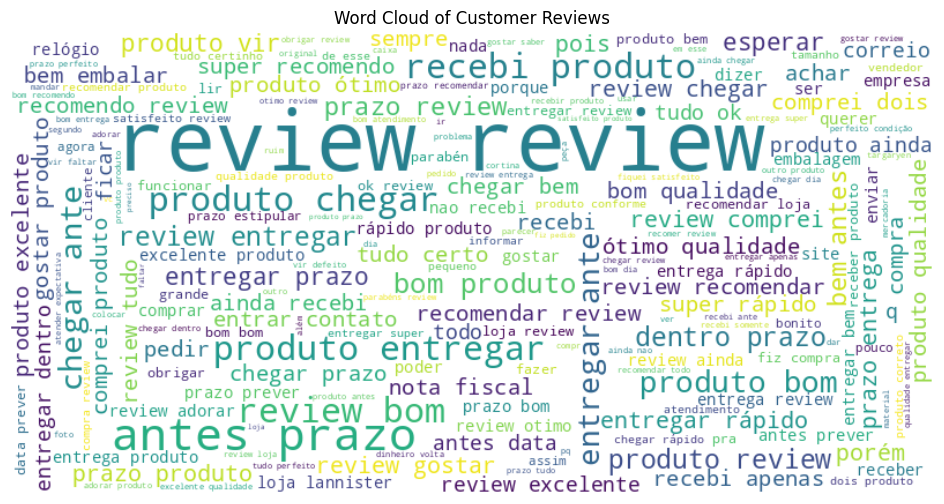

In [110]:
text = " ".join(df_new["clean_review"].dropna())

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Customer Reviews")
plt.show()

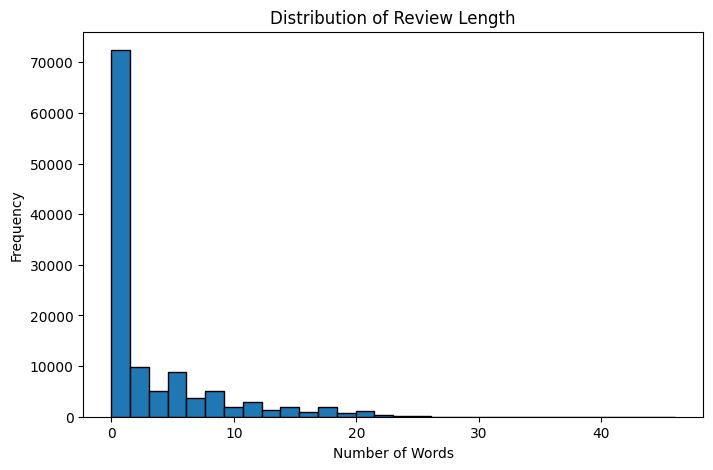

In [111]:
#Distribution of Review Length
df_new["review_length"] = df_new["clean_review"].str.split().str.len()

plt.figure(figsize=(8,5))
plt.hist(df_new["review_length"], bins=30, edgecolor="black")
plt.title("Distribution of Review Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

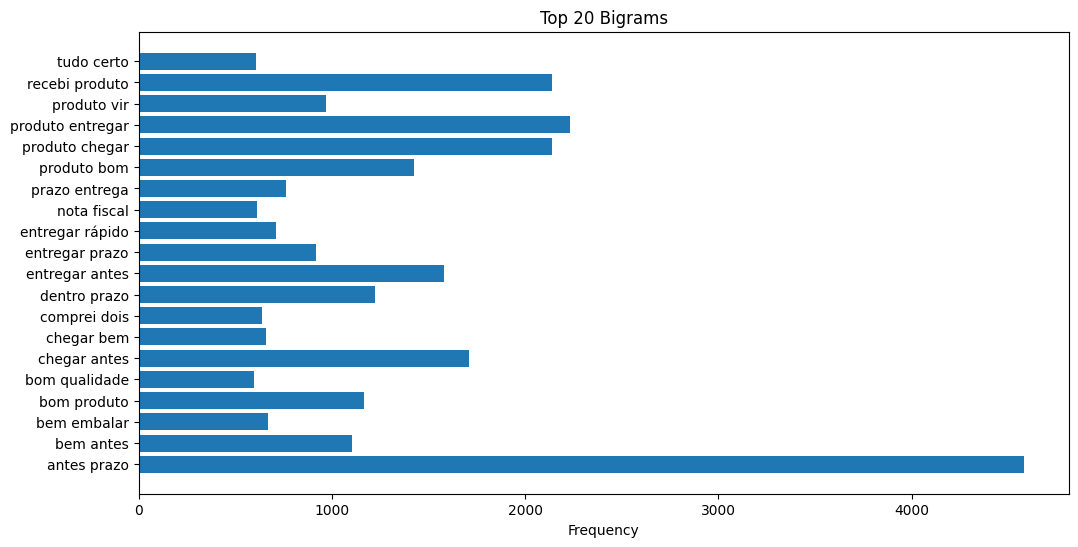

In [112]:
#Top 20 Most Frequent Words
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=20)

X = vectorizer.fit_transform(df_new["clean_review"].fillna(""))

counts = X.sum(axis=0).A1
bigrams = vectorizer.get_feature_names_out()

plt.figure(figsize=(12,6))
plt.barh(bigrams, counts)
plt.title("Top 20 Bigrams")
plt.xlabel("Frequency")
plt.show()

In [113]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df_new['clean_review'],
    df_new['sentiment_encoded'],
    test_size=0.2,
    random_state=42,
    stratify=df_new['sentiment_encoded']
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (94516,)
X_test shape: (23630,)
y_train shape: (94516,)
y_test shape: (23630,)


In [114]:
# Initialize BERTimbau tokenizer and model
if BERTIMBAU_INSTALLED:
    model_name = "neuralmind/bert-base-portuguese-cased"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(label_encoder.classes_))
    print("BERTimbau tokenizer and model loaded successfully.")
else:
    print("BERTimbau libraries (torch, transformers) not installed. Skipping model initialization.")

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

BERTimbau tokenizer and model loaded successfully.


In [115]:
# Tokenize the training and test data
if BERTIMBAU_INSTALLED:
    X_train_tokenized = tokenizer(list(X_train.astype(str)), truncation=True, padding=True, max_length=128, return_tensors='pt')
    X_test_tokenized = tokenizer(list(X_test.astype(str)), truncation=True, padding=True, max_length=128, return_tensors='pt')
    print("Training and test data tokenized successfully.")
else:
    print("BERTimbau libraries not installed. Skipping data tokenization.")

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Training and test data tokenized successfully.


In [116]:
# Create PyTorch Dataset objects
import torch

class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

if BERTIMBAU_INSTALLED:
    train_dataset = SentimentDataset(X_train_tokenized, y_train)
    test_dataset = SentimentDataset(X_test_tokenized, y_test)
    print("PyTorch Datasets created successfully.")
else:
    print("BERTimbau libraries not installed. Skipping Dataset creation.")

PyTorch Datasets created successfully.


In [117]:


# Define a function to initialize the model for each trial
def model_init():
    if BERTIMBAU_INSTALLED:
        return AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=len(label_encoder.classes_))
    else:
        raise ImportError("BERTimbau libraries not installed. Cannot initialize model.")

# Define a compute_metrics function for the Trainer
def compute_metrics(p):
    predictions = np.argmax(p.predictions, axis=1)
    f1 = f1_score(p.label_ids, predictions, average='weighted') # Using weighted F1 for multi-class
    return {"f1": f1}

print("Model initialization and compute_metrics functions defined.")

Model initialization and compute_metrics functions defined.


In [118]:
if BERTIMBAU_INSTALLED:
    training_args = TrainingArguments(
        output_dir='./results',
        num_train_epochs=2,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        warmup_steps=500,
        weight_decay=0.01,
        logging_dir='./logs',
        logging_steps=10,
        eval_strategy="epoch", # Changed from evaluation_strategy
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1", # Choose a suitable metric, e.g., f1 for imbalanced datasets
        greater_is_better=True,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics
    )
    print("Trainer initialized with training arguments.")
else:
    print("BERTimbau libraries not installed. Skipping Trainer initialization.")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer initialized with training arguments.


In [119]:
# Start model training
if BERTIMBAU_INSTALLED:
    print("Starting model training...")
    trainer.train()
    print("Model training complete.")
else:
    print("BERTimbau libraries not installed. Skipping model training.")

Starting model training...


Epoch,Training Loss,Validation Loss,F1
1,0.481453,0.477857,0.817994
2,0.542716,0.468857,0.833254


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model training complete.


###### Predict Sentiment with the Trained BERTimbau Model

In [120]:
if BERTIMBAU_INSTALLED:
    def predict_sentiment(texts):
        # Ensure input is a list of strings
        if isinstance(texts, str):
            texts = [texts]

        # Clean and tokenize the texts
        cleaned_texts = [clean_text(text) for text in texts]
        tokenized_inputs = tokenizer(
            cleaned_texts,
            truncation=True,
            padding=True,
            max_length=128,
            return_tensors='pt'
        )

        # Move tensors to GPU if available
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model.to(device)
        tokenized_inputs = {k: v.to(device) for k, v in tokenized_inputs.items()}

        # Make predictions
        with torch.no_grad():
            outputs = model(**tokenized_inputs)

        # Get predicted class (the one with the highest logit)
        predictions = torch.argmax(outputs.logits, dim=-1)

        # Decode predictions back to sentiment labels
        # Assuming label_encoder is still available from earlier
        predicted_labels = label_encoder.inverse_transform(predictions.cpu().numpy())
        return predicted_labels

    print("Sentiment prediction function defined.")
else:
    print("BERTimbau libraries not installed. Skipping sentiment prediction function definition.")

Sentiment prediction function defined.


####Sentiment Prediction

In [121]:
if BERTIMBAU_INSTALLED:
    # Example usage
    example_reviews = [
        "O produto chegou super rápido e em perfeitas condições! Adorei!", # Positive
        "Demorou muito para chegar e veio com defeito. Muito insatisfeito.", # Negative
        "É um produto ok. Nada de espetacular, mas funciona.", # Neutral
        "Nunca mais compro nesta loja! Terrível experiência." # Negative
    ]

    predicted_sentiments = predict_sentiment(example_reviews)

    for review, sentiment in zip(example_reviews, predicted_sentiments):
        print(f"Review: '{review}'\nPredicted Sentiment: {sentiment}\n")
else:
    print("BERTimbau libraries not installed. Skipping sentiment prediction demo.")

Review: 'O produto chegou super rápido e em perfeitas condições! Adorei!'
Predicted Sentiment: Positive

Review: 'Demorou muito para chegar e veio com defeito. Muito insatisfeito.'
Predicted Sentiment: Negative

Review: 'É um produto ok. Nada de espetacular, mas funciona.'
Predicted Sentiment: Positive

Review: 'Nunca mais compro nesta loja! Terrível experiência.'
Predicted Sentiment: Negative



### BERTimbau Model Evaluation

Evaluating the BERTimbau model...



BERTimbau Model Classification Report:
              precision    recall  f1-score   support

    Negative     0.8274    0.6792    0.7460      3918
     Neutral     0.4786    0.1243    0.1974      1979
    Positive     0.8732    0.9799    0.9235     17733

    accuracy                         0.8584     23630
   macro avg     0.7264    0.5945    0.6223     23630
weighted avg     0.8326    0.8584    0.8333     23630



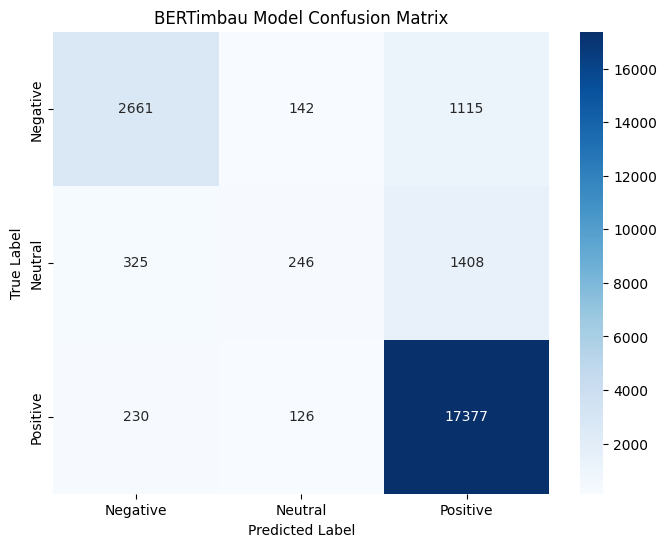

In [122]:
if BERTIMBAU_INSTALLED:
    print("Evaluating the BERTimbau model...")

    # Get predictions from the trainer
    bertimbau_predictions= trainer.predict(test_dataset)
    bertimbau_predictions_raw = bertimbau_predictions.predictions
    bertimbau_predicted_labels = np.argmax(bertimbau_predictions_raw, axis=1)

    # Get true labels
    bertimbau_true_labels = test_dataset.labels.to_numpy()

    # Generate Classification Report
    print("\nBERTimbau Model Classification Report:")
    print(classification_report(
        bertimbau_true_labels,
        bertimbau_predicted_labels,
        target_names=label_encoder.classes_,
        digits=4
    ))

    # Generate Confusion Matrix
    cm_bertimbau = confusion_matrix(bertimbau_true_labels, bertimbau_predicted_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm_bertimbau,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_
    )
    plt.title('BERTimbau Model Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
else:
    print("BERTimbau libraries not installed. Skipping model evaluation.")

###Baseline Model: TF-IDF with Logistic Regression

In [123]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

print("Training a baseline model (TF-IDF + Logistic Regression)...")

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limit features for simplicity

# Fit and transform training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train.astype(str))
X_test_tfidf = tfidf_vectorizer.transform(X_test.astype(str))

# Initialize and train Logistic Regression model
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_tfidf, y_train)

print("Baseline model trained successfully.")

Training a baseline model (TF-IDF + Logistic Regression)...
Baseline model trained successfully.


In [129]:
# Save the TF-IDF vectorizer and baseline model
model_save_path = '/content/drive/MyDrive/Colab Notebooks/IIT Palakkad Advanced AI/'
joblib.dump(tfidf_vectorizer, model_save_path + 'tfidf_vectorizer.pkl')
joblib.dump(baseline_model, model_save_path + 'baseline_model.pkl')
print("TF-IDF vectorizer and Baseline model saved successfully.")

TF-IDF vectorizer and Baseline model saved successfully.


######Model Evaluation

Evaluating the baseline model...

Baseline Model Classification Report:
              precision    recall  f1-score   support

    Negative     0.7812    0.6751    0.7243      3918
     Neutral     0.5200    0.0526    0.0955      1979
    Positive     0.8650    0.9778    0.9180     17733

    accuracy                         0.8501     23630
   macro avg     0.7221    0.5685    0.5792     23630
weighted avg     0.8222    0.8501    0.8170     23630



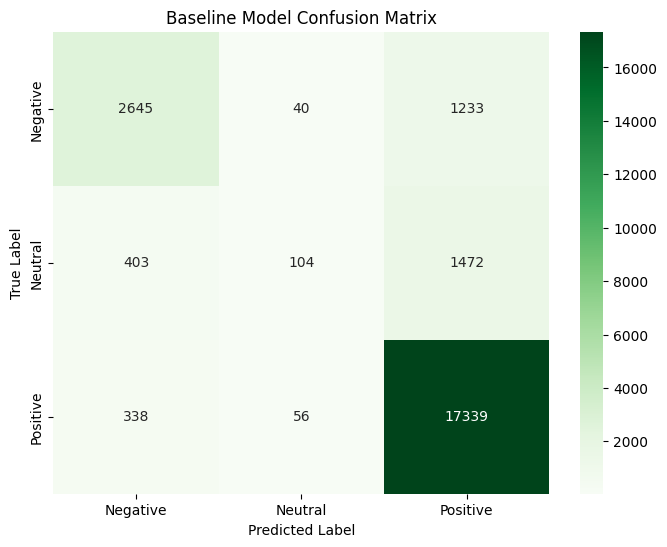

In [124]:
print("Evaluating the baseline model...")

# Make predictions on the test set
baseline_predictions = baseline_model.predict(X_test_tfidf)

# Generate Classification Report
print("\nBaseline Model Classification Report:")
print(classification_report(
    y_test,
    baseline_predictions,
    target_names=label_encoder.classes_,
    digits=4
))

# Generate Confusion Matrix
cm_baseline = confusion_matrix(y_test, baseline_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_baseline,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title('Baseline Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Loading Saved Models



In [125]:
trainer.save_model("/content/drive/MyDrive/Colab Notebooks/IIT Palakkad Advanced AI/bertimbau_sentiment")
tokenizer.save_pretrained("/content/drive/MyDrive/Colab Notebooks/IIT Palakkad Advanced AI/bertimbau_sentiment")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/Colab Notebooks/IIT Palakkad Advanced AI/bertimbau_sentiment/tokenizer_config.json',
 '/content/drive/MyDrive/Colab Notebooks/IIT Palakkad Advanced AI/bertimbau_sentiment/tokenizer.json')

In [130]:
import joblib

# Assuming these models/encoders are saved in the same directory as the BERTimbau model
model_save_path = '/content/drive/MyDrive/Colab Notebooks/IIT Palakkad Advanced AI/'

try:
    # Load the feature encoder
    feature_encoder = joblib.load(model_save_path + 'feature_encoder.pkl')
    print('Loaded feature_encoder:')
    print(feature_encoder)

    # Load the label encoder
    label_encoder = joblib.load(model_save_path + 'label_encoder.pkl')
    print('\nLoaded label_encoder:')
    print(label_encoder)

    # Load the TF-IDF vectorizer
    tfidf_vectorizer = joblib.load(model_save_path + 'tfidf_vectorizer.pkl')
    print('\nLoaded tfidf_vectorizer:')
    print(tfidf_vectorizer)

    # Load the baseline model
    baseline_model = joblib.load(model_save_path + 'baseline_model.pkl')
    print('\nLoaded baseline_model:')
    print(baseline_model)
except FileNotFoundError as e:
    print(f"Error loading model components: {e}")
    print("It seems the feature_encoder, label_encoder, tfidf_vectorizer, or baseline_model were not saved. Please make sure they are saved to the specified path before attempting to load them.")



Loaded feature_encoder:

Loaded label_encoder:
LabelEncoder()

Loaded tfidf_vectorizer:
TfidfVectorizer(max_features=5000)

Loaded baseline_model:
LogisticRegression(max_iter=1000, random_state=42)
